Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

First 5 rows:
Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing %:
 show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.0

/tmp/ipykernel_12738/754885862.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown", inplace=True)
/tmp/ipykernel_12738/754885862.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

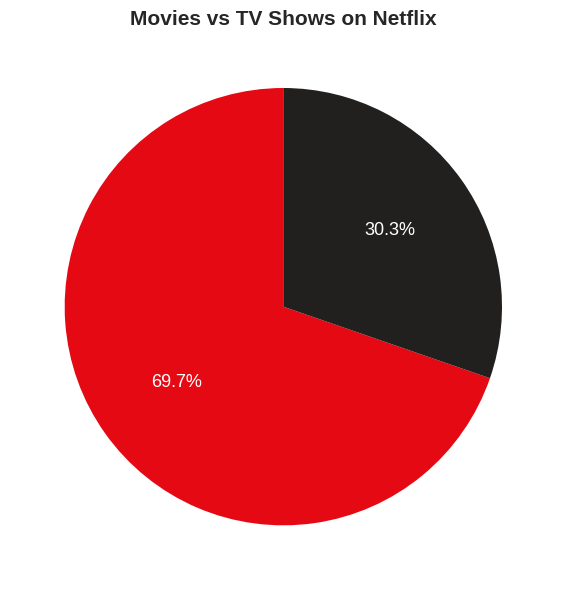

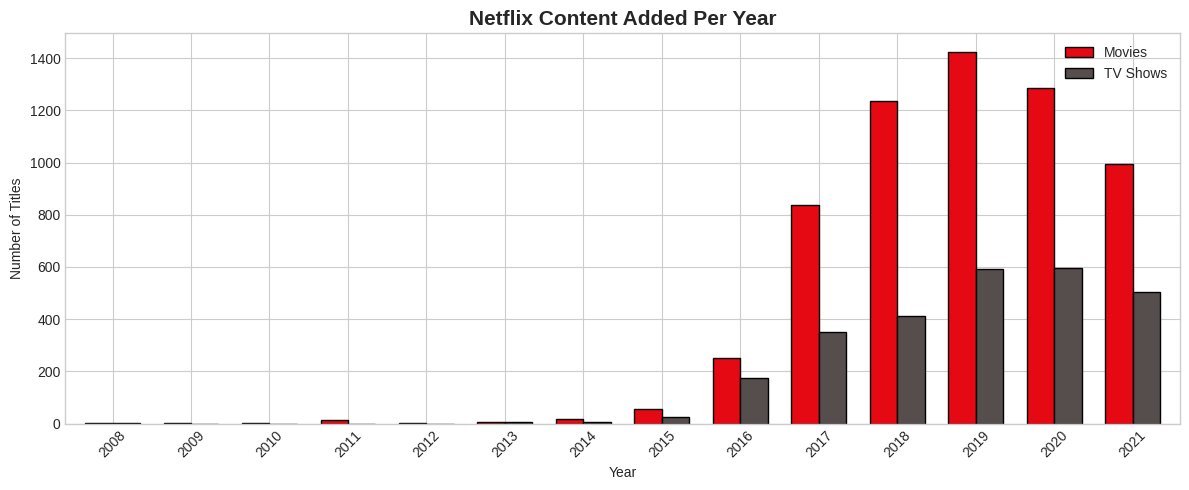

/tmp/ipykernel_12738/754885862.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette="Reds_r")


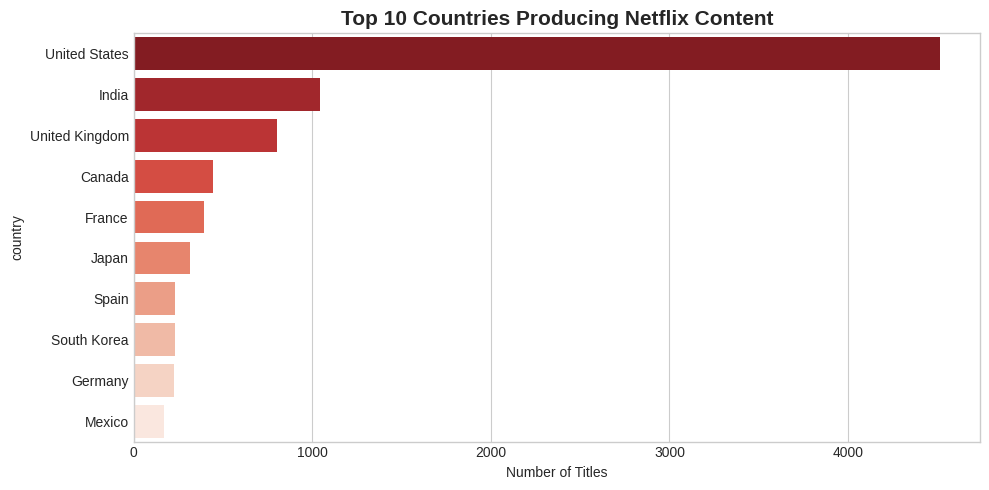

/tmp/ipykernel_12738/754885862.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_genres.values, y=all_genres.index, palette="Blues_r")


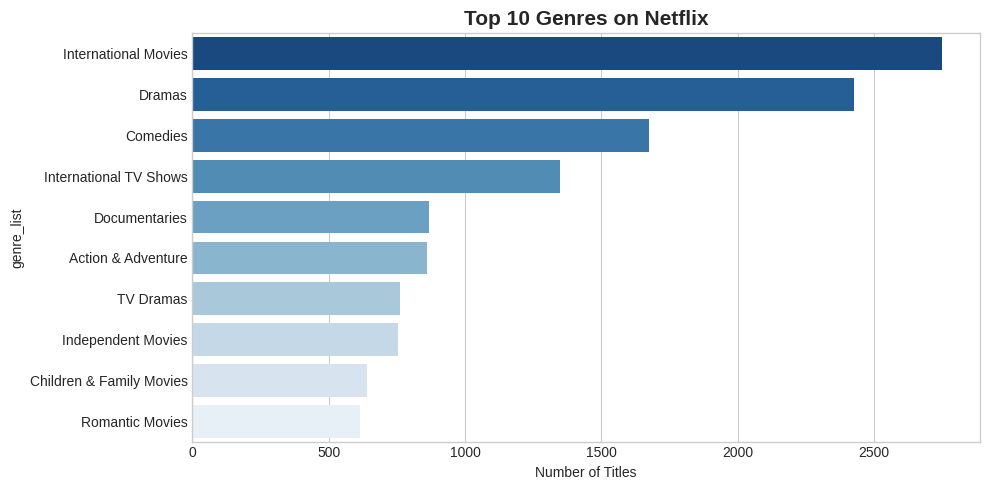

/tmp/ipykernel_12738/754885862.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="coolwarm")


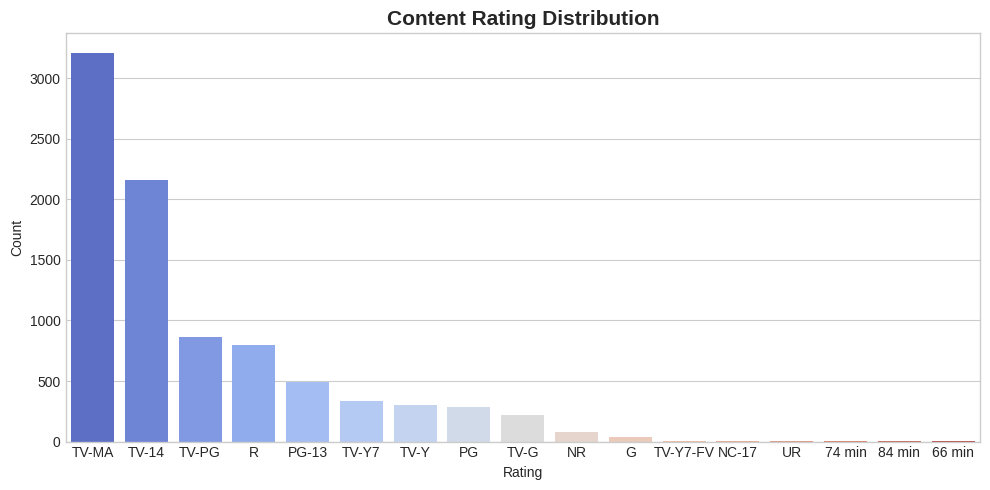

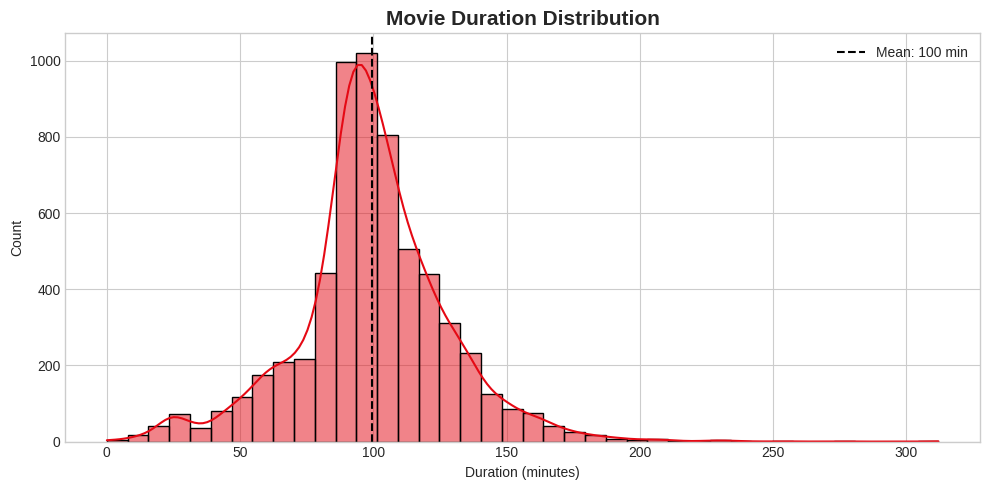

/tmp/ipykernel_12738/754885862.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette="Greens_r")


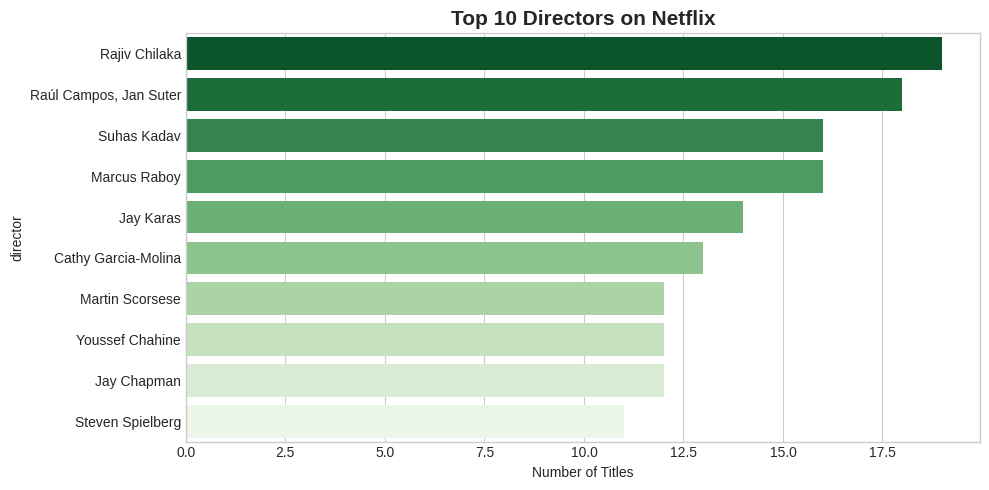

       NETFLIX DATA ANALYSIS — KEY INSIGHTS

 Total Titles Analysed     : 8,797
 Total Movies              : 6,131
 Total TV Shows            : 2,666
 Countries Represented     : 127
 Unique Genres             : 42

 Most Content Added In     : 2019
 Top Producing Country     : United States
 Most Common Genre         : International Movies
 Most Common Rating        : TV-MA

⏱  Avg Movie Duration        : 100 minutes
⏱ Longest Movie             : 312 minutes
⏱  Shortest Movie            : 0 minutes

 Avg TV Show Seasons       : 1.8 seasons
 Max Seasons (TV Show)     : 17 seasons

Analysis Complete!
Report saved as netflix_analysis_report.csv
                      Metric                 Value
0               Total Titles                  8797
1               Total Movies                  6131
2             Total TV Shows                  2666
3                  Countries                   127
4              Unique Genres                    42
5          Most Content Year               

In [3]:
## Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

plt.style.use("seaborn-v0_8-whitegrid")

## Load & First Look
df = pd.read_csv("/content/drive/MyDrive/projects for resume/netflix_titles.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

## Data Cleaning

# Check missing values
print("Missing Values:\n", df.isnull().sum())
print("\nMissing %:\n", (df.isnull().sum() / len(df) * 100).round(2))

# Fill missing values
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna(df["country"].mode()[0], inplace=True)
df["rating"].fillna(df["rating"].mode()[0], inplace=True)
df["duration"].fillna("0 min", inplace=True)

# Drop rows where date_added is missing
df.dropna(subset=["date_added"], inplace=True)

# Clean date_added column
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

print("\nAfter Cleaning — Missing Values:\n", df.isnull().sum())
print("Final Shape:", df.shape)

## Data Transformation

# Extract movie duration in minutes
movies = df[df["type"] == "Movie"].copy()
movies["duration_mins"] = movies["duration"].str.extract(r'(\d+)').astype(int)

# Extract TV show seasons
shows = df[df["type"] == "TV Show"].copy()
shows["seasons"] = shows["duration"].str.extract(r'(\d+)').astype(int)

# Split listed_in (genres) into individual genres
df["genre_list"] = df["listed_in"].str.split(", ")

print("Movies shape:", movies.shape)
print("TV Shows shape:", shows.shape)

## Analysis & Visualizations

# 5a — Movies vs TV Shows Split
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
        colors=["#E50914", "#221F1F"], startangle=90,
        textprops={"color": "white", "fontsize": 13})
plt.title("Movies vs TV Shows on Netflix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("movies_vs_shows.png", dpi=150, bbox_inches="tight")
plt.show()

# 5b — Content Added Per Year
yearly = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)

yearly.plot(kind="bar", figsize=(12,5), color=["#E50914", "#564d4d"],
            edgecolor="black", width=0.7)
plt.title("Netflix Content Added Per Year", fontsize=15, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(["Movies", "TV Shows"])
plt.tight_layout()
plt.savefig("content_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

# 5c — Top 10 Countries
country_counts = df["country"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.values, y=country_counts.index, palette="Reds_r")
plt.title("Top 10 Countries Producing Netflix Content", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("top_countries.png", dpi=150, bbox_inches="tight")
plt.show()

# 5d — Top 10 Genres
all_genres = df["genre_list"].explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=all_genres.values, y=all_genres.index, palette="Blues_r")
plt.title("Top 10 Genres on Netflix", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("top_genres.png", dpi=150, bbox_inches="tight")
plt.show()

# 5e — Content Rating Distribution
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="coolwarm")
plt.title("Content Rating Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 5f — Movie Duration Distribution
plt.figure(figsize=(10,5))
sns.histplot(movies["duration_mins"], bins=40, kde=True, color="#E50914")
plt.title("Movie Duration Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Duration (minutes)")
plt.axvline(movies["duration_mins"].mean(), color="black",
            linestyle="--", label=f'Mean: {movies["duration_mins"].mean():.0f} min')
plt.legend()
plt.tight_layout()
plt.savefig("movie_duration.png", dpi=150, bbox_inches="tight")
plt.show()

# 5g — Top 10 Directors
top_directors = df[df["director"] != "Unknown"]["director"]\
    .value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette="Greens_r")
plt.title("Top 10 Directors on Netflix", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("top_directors.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Insights Report
print("=" * 55)
print("       NETFLIX DATA ANALYSIS — KEY INSIGHTS")
print("=" * 55)

print(f"\n Total Titles Analysed     : {len(df):,}")
print(f" Total Movies              : {len(movies):,}")
print(f" Total TV Shows            : {len(shows):,}")
print(f" Countries Represented     : {df['country'].str.split(', ').explode().nunique()}")
print(f" Unique Genres             : {df['genre_list'].explode().nunique()}")

print(f"\n Most Content Added In     : {int(df['year_added'].mode()[0])}")
print(f" Top Producing Country     : {df['country'].str.split(', ').explode().value_counts().index[0]}")
print(f" Most Common Genre         : {df['genre_list'].explode().value_counts().index[0]}")
print(f" Most Common Rating        : {df['rating'].mode()[0]}")

print(f"\n⏱  Avg Movie Duration        : {movies['duration_mins'].mean():.0f} minutes")
print(f"⏱ Longest Movie             : {movies['duration_mins'].max()} minutes")
print(f"⏱  Shortest Movie            : {movies['duration_mins'].min()} minutes")

print(f"\n Avg TV Show Seasons       : {shows['seasons'].mean():.1f} seasons")
print(f" Max Seasons (TV Show)     : {shows['seasons'].max()} seasons")

print("\n" + "=" * 55)
print("Analysis Complete!")
print("=" * 55)

## Export Summary Report to CSV
summary = {
    "Metric": [
        "Total Titles", "Total Movies", "Total TV Shows",
        "Countries", "Unique Genres", "Most Content Year",
        "Top Country", "Top Genre", "Most Common Rating",
        "Avg Movie Duration (mins)"
    ],
    "Value": [
        len(df), len(movies), len(shows),
        df["country"].str.split(", ").explode().nunique(),
        df["genre_list"].explode().nunique(),
        int(df["year_added"].mode()[0]),
        df["country"].str.split(", ").explode().value_counts().index[0],
        df["genre_list"].explode().value_counts().index[0],
        df["rating"].mode()[0],
        f"{movies['duration_mins'].mean():.0f}"
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv("netflix_analysis_report.csv", index=False)
print("Report saved as netflix_analysis_report.csv")
print(summary_df)